# Import Packages

In [1]:
import pandas as pd
import numpy  as np
import scipy.stats as sp
import matplotlib.pyplot as plt
import pywt

In [2]:
# Mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔗 Cloning a GitHub Repository

In this notebook, we **clone** the repository into the `/content` folder, which is the working directory in Colab.


In [7]:
!git clone https://github.com/ljwg3000/UNT_MEEN.git

Cloning into 'UNT_MEEN'...
remote: Enumerating objects: 7728, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 7728 (delta 2), reused 4 (delta 1), pack-reused 7718 (from 3)
Receiving objects: 100% (7728/7728), 827.52 MiB | 23.03 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (5669/5669), done.


In [8]:
data_path = "/content/UNT_MEEN/AI_tutorial/IMS_dataset/2nd_test/"

- **`os` package**: A built-in Python library that allows us to interact with the operating system, such as accessing folders and files.  

- **`os.listdir(path)`**: Returns all file names inside the specified folder.  

- **`sorted(...)`**: Makes sure that the file names are ordered consistently.  

👉 By storing all file names in a list, we can later use a loop (`for`) to load the data files one by one.  
This way, we don’t have to type file names manually, and we also reduce the chance of making mistakes.


In [9]:
import os

file_list = sorted(os.listdir(data_path))
print("Number of files:", len(file_list))
print(file_list[:3])

Number of files: 984
['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39']


## 📊 About the NASA IMS Bearing Dataset (2nd_test)

The dataset we are using comes from the **IMS Bearing Data** collected at the University of Cincinnati’s Center for Intelligent Maintenance Systems (IMS).
It was generated using a test rig where four bearings were mounted on a rotating shaft under constant load and speed until failure occurred.

- **Experiment setup**:  
  - Shaft rotating at 2000 RPM with a radial load of 6000 lbs.  
  - Four Rexnord ZA-2115 bearings installed on the shaft.  
  - Accelerometers mounted on each bearing to record vibration data.  

- **2nd_test dataset**:  
  - Duration: February 12–19, 2004.  
  - **984 files** in total.  
  - **4 channels** (one for each bearing).  
  - Each file contains a **1-second vibration signal** (20,480 points, sampled at 20 kHz).  
  - Data recorded every **10 minutes**.  
  - At the end of the test, **Bearing 1 failed (outer race failure)**.  

👉 In this tutorial, we will use this 2nd test dataset to extract features and visualize the Bearing 1's failure progress.


In [10]:
for i in range(len(file_list)):
    temp_PATH = data_path + file_list[i]
    temp_DATA = pd.read_csv(temp_PATH, sep='\t', names=['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4'])
    exec(f"Data_{i+1} = temp_DATA")

Data_1

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
0,-0.049,-0.071,-0.132,-0.010
1,-0.042,-0.073,-0.007,-0.105
2,0.015,0.000,0.007,0.000
3,-0.051,0.020,-0.002,0.100
4,-0.107,0.010,0.127,0.054
...,...,...,...,...
20475,0.049,-0.051,-0.039,-0.044
20476,0.037,0.061,0.115,0.007
20477,-0.012,0.007,0.056,-0.007
20478,-0.012,0.093,0.017,-0.044


### Time-domain plots of Bearing 1–4 signals (acceleration)

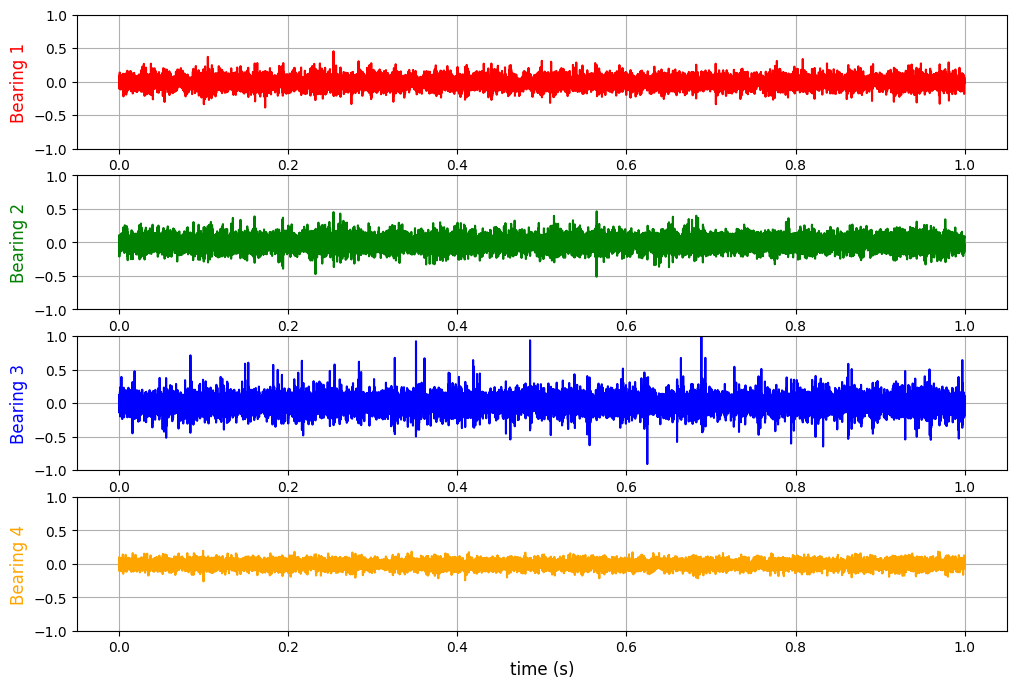

In [11]:
time = np.arange(0, 1, 1/20480)

plt.figure(figsize=(12,8))

plt.subplot(4,1,1) #
plt.plot(time , Data_1.iloc[:,0], color='r')
plt.ylabel('Bearing 1', fontsize=12, color='r')
plt.ylim(-1, 1)
plt.grid()

plt.subplot(4,1,2) #
plt.plot(time , Data_1.iloc[:,1], color='g')
plt.ylabel('Bearing 2', fontsize=12, color='g')
plt.ylim(-1, 1)
plt.grid()

plt.subplot(4,1,3) #
plt.plot(time , Data_1.iloc[:,2], color='b')
plt.ylabel('Bearing 3',fontsize=12, color='b')
plt.xlabel('time (s)', fontsize=12)
plt.ylim(-1, 1)
plt.grid()

plt.subplot(4,1,4) #
plt.plot(time , Data_1.iloc[:,3], color='orange')
plt.ylabel('Bearing 4',fontsize=12, color='orange')
plt.xlabel('time (s)', fontsize=12)
plt.ylim(-1, 1)
plt.grid()

plt.show()

.

.

.

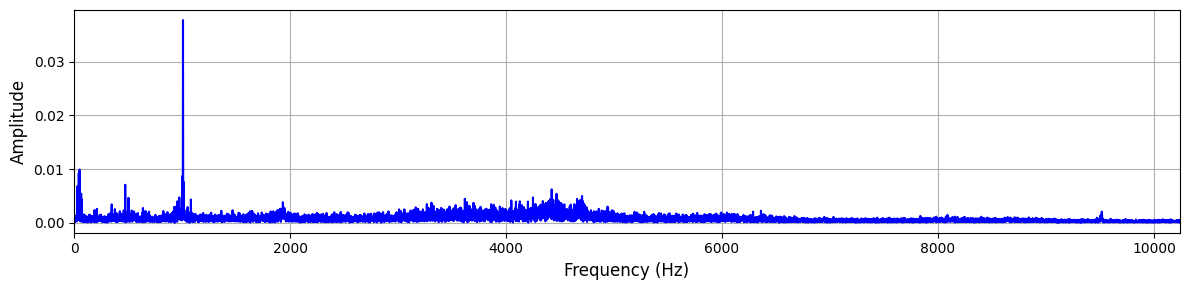

In [12]:
from scipy.fft import fft, fftfreq

t = time
x = Data_100.iloc[:,0]

dt = np.mean(np.diff(t))
fs = 1.0 / dt

N = len(x)
X = fft(x)
freq = fftfreq(N, 1/fs)

# single-sided
k_pos = N//2
f_pos = freq[:k_pos]
X_pos = X[:k_pos]

# Amplitude scaling
amp = (2 / N) * np.abs(X_pos)
amp[0] = amp[0] / 2
amp[-1] = amp[-1] / 2

plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'b-')
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

Peak frequencies: [  30.   37.   44.   51.   66.  474. 1001. 1009. 1016. 4423. 4468.]
Peak amplitudes: [0.006743   0.00646993 0.00924141 0.00989513 0.00539638 0.00706139
 0.00863487 0.03778789 0.00757615 0.0061981  0.00538381]


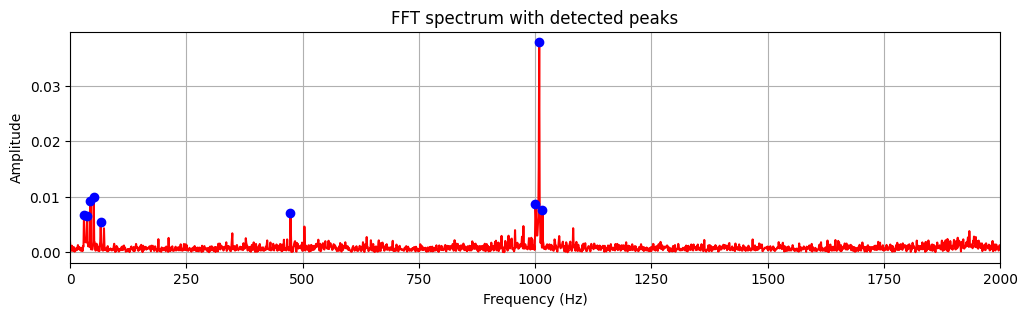

In [13]:
from scipy.signal import find_peaks

# suppose we already have f_pos (Hz) and amp (amplitude spectrum)
peaks, props = find_peaks(amp, height=0.005)  # only peaks above 0.5

# peak frequencies & amplitudes
peak_freqs = f_pos[peaks]
peak_amps = amp[peaks]

print("Peak frequencies:", peak_freqs)
print("Peak amplitudes:", peak_amps)

# plot with peaks marked
plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'r-')
plt.plot(peak_freqs, peak_amps, 'bo')   # mark peaks
plt.xlim(0, 2000);
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT spectrum with detected peaks")
plt.grid(True)
plt.show()

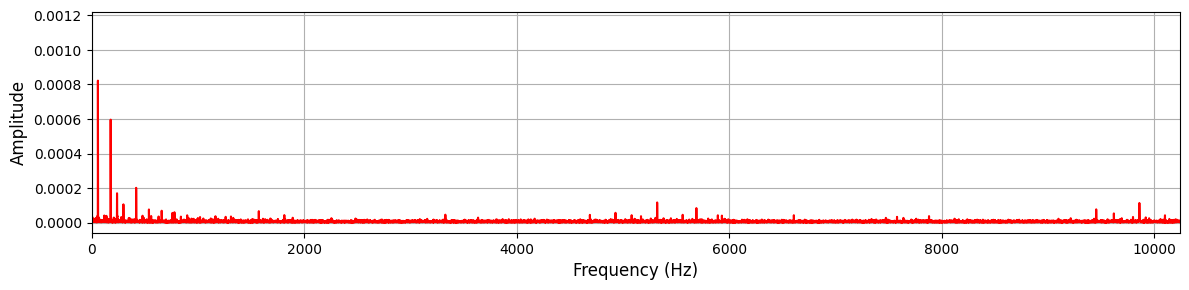

In [14]:
t = time
x = Data_984.iloc[:,0]

dt = np.mean(np.diff(t))
fs = 1.0 / dt

N = len(x)
X = fft(x)
freq = fftfreq(N, 1/fs)

# single-sided
k_pos = N//2
f_pos = freq[:k_pos]
X_pos = X[:k_pos]

# Amplitude scaling
amp = (2 / N) * np.abs(X_pos)
amp[0] = amp[0] / 2
amp[-1] = amp[-1] / 2

plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'r-')
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()



Peak frequencies: [  60.  180.  240.  300.  420. 5322. 9859.]
Peak amplitudes: [0.00082212 0.0005962  0.00017022 0.00010609 0.00020183 0.00011707
 0.00011407]


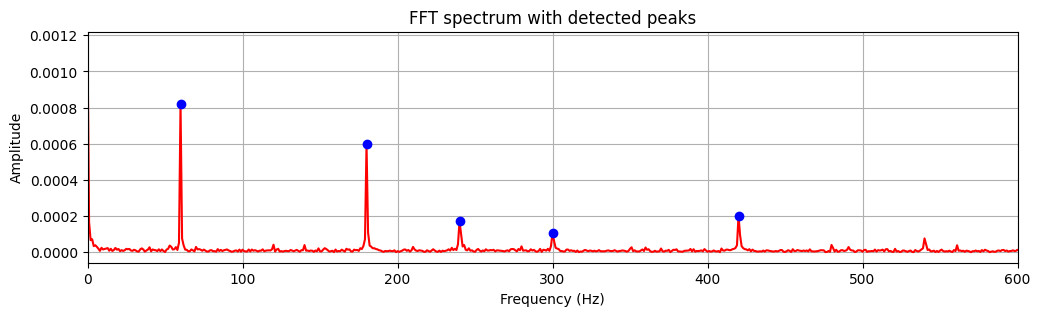

In [15]:
from scipy.signal import find_peaks

# suppose we already have f_pos (Hz) and amp (amplitude spectrum)
peaks, props = find_peaks(amp, height=0.0001)  # only peaks above 0.5

# peak frequencies & amplitudes
peak_freqs = f_pos[peaks]
peak_amps = amp[peaks]

print("Peak frequencies:", peak_freqs)
print("Peak amplitudes:", peak_amps)

# plot with peaks marked
plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'r-')
plt.plot(peak_freqs, peak_amps, 'bo')   # mark peaks
plt.xlim(0, 600)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT spectrum with detected peaks")
plt.grid(True)
plt.show()

.

.

.

## 🔧 Feature Extraction for Bearing 1

Now we will extract features from the vibration signals of **Bearing 1** only.  
Remember that in the dataset we loaded, there are a total of **984 files (data samples)**, and we will compute time-domain features for each of them.

### **Task for you:**
Use the provided code from **DA3_Code1** as a reference, but **modify it appropriately** for this dataset:
- Use only the **first column** of each data file as the input signal.  
- Exaract 10 features (Max, Min, Mean, RMS, Variance, Skewness, Kurtosis, Crest factor, Shape factor, Impulse factor) for each of the 984 samples.

### **Key points to keep in mind:**
- Unlike the example datasets used in **DA3 and 4**, here the **first column is not time** but directly the signal.  
  - So be careful when applying functions like `np.max(...)` or `rms(...)` — the indexing in `temp_data.iloc[:, j+1]` should be checked carefully..

- We are focusing on **only Bearing 1**, which corresponds to the **first column** of each data file.  
  - This means `NoOfSensor = 1`.  
  - Since there is only one signal, you don’t necessarily need the loop `for j in range(NoOfSensor):`.

- The dataset is **not divided into Normal and Abnormal groups**.  
  - We simply have 984 data samples.  
  - Therefore, there is no need to create separate arrays like `TimeFeature_Normal` or `TimeFeature_Abnormal`. A single `TimeFeature` array will be enough.


By making these adjustments, you will be able to correctly extract features for Bearing 1 from this dataset.


In [16]:
NoOfData    = 984  # Number of data samples
NoOfSensor  = 1    # Only Bearing 1 signal
NoOfFeature = 10   # 10 types of feature

NoOfData, NoOfSensor, NoOfFeature

(984, 1, 10)

In [17]:
# Define RMS function
def rms(x):
    return np.sqrt(np.mean(x**2))

In [18]:
# Create empty(0) arrays for time domin feature dataset (no need to separate normal/abnormal)
# The shape of TimeFeature should be "(10, 984)"
TimeFeature   = np.zeros((NoOfSensor*NoOfFeature , NoOfData))

print(TimeFeature.shape)
TimeFeature

(10, 984)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### **Time Domain Feature Extraction**

In [22]:
for i in range(NoOfData):

    # Declare temporary data
    exec(f"temp_data = Data_{i+1}")

    # We don't need a base_index as we have only one sensor

    signal = temp_data.iloc[:,0]

    # Features
    TimeFeature[0, i] = np.max(signal)
    TimeFeature[1, i] = np.min(signal)
    TimeFeature[2, i] = np.mean(signal)
    TimeFeature[3, i] = rms(signal)
    TimeFeature[4, i] = np.var(signal)
    TimeFeature[5, i] = sp.skew(signal)
    TimeFeature[6, i] = sp.kurtosis(signal)
    TimeFeature[7, i] = np.max(signal)/rms(signal)
    TimeFeature[8, i] = rms(signal)/np.mean(np.abs(signal))
    TimeFeature[9, i] = np.max(signal)/np.mean(np.abs(signal))

print(TimeFeature.shape)
TimeFeature

(10, 984)


array([[ 4.54000000e-01,  3.69000000e-01,  5.03000000e-01, ...,
         3.50100000e+00,  5.00000000e-03,  2.00000000e-03],
       [-3.86000000e-01, -3.88000000e-01, -4.00000000e-01, ...,
        -3.69600000e+00,  0.00000000e+00, -5.00000000e-03],
       [-1.01959961e-02, -2.58500977e-03, -2.48398437e-03, ...,
        -1.70307617e-03,  1.85683594e-03, -1.16196289e-03],
       ...,
       [ 6.12033067e+00,  4.89503812e+00,  6.59847157e+00, ...,
         7.23593196e+00,  2.37754317e+00,  1.30485950e+00],
       [ 1.27165985e+00,  1.27774172e+00,  1.26545625e+00, ...,
         1.37807747e+00,  1.13257784e+00,  1.31181214e+00],
       [ 7.78297875e+00,  6.25459445e+00,  8.35007709e+00, ...,
         9.97167479e+00,  2.69275271e+00,  1.71173054e+00]])

.

.

### **Frequency Domain Feature Extraction**

- Set MotherWavelet as `sym4`
- Set WT level as `3`
- Again, no need to separate Normal/Abnormal FreqFeature array.
- Again, be careful of indexing when extracting each feature.
   - *There is no time array on the first column.*

In [20]:
# Wavelet Transform parameter setting
MotherWavelet = pywt.Wavelet('sym4')   # Mother wavelet
Level   = 3                            # Wavelet decomposition level

In [21]:
# Create empty(0) arrays for frequency domin feature dataset (no need to separate normal/abnormal)
# The shape of FreqFeature should be "(30, 984)"
FreqFeature = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))

print(FreqFeature.shape)
FreqFeature

(30, 984)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
# Fill FreqFeaure array with features extracted
for i in range(NoOfData):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data = Data_{i+1}")

    # Walvelet decomposition
    Coef = pywt.wavedec(temp_data, MotherWavelet, level=Level, axis=0)

    for k in np.arange(Level):

        # We only need a base_index for decomposition levels
        base_index = NoOfFeature * k

        # Select a wavelet coefficient using k
        coef   = Coef[Level-k]
        signal = coef[:,0]

        # features
        FreqFeature[base_index + 0 , i] = np.max(signal)
        FreqFeature[base_index + 1 , i] = np.min(signal)
        FreqFeature[base_index + 2 , i] = np.mean(signal)
        FreqFeature[base_index + 3 , i] = rms(signal)
        FreqFeature[base_index + 4 , i] = np.var(signal)
        FreqFeature[base_index + 5 , i] = sp.skew(signal)
        FreqFeature[base_index + 6 , i] = sp.kurtosis(signal)
        FreqFeature[base_index + 7 , i] = np.max(signal)/rms(signal)
        FreqFeature[base_index + 8 , i] = rms(signal)/np.mean(np.abs(signal))
        FreqFeature[base_index + 9 , i] = np.max(signal)/np.mean(np.abs(signal))

print(FreqFeature.shape)
FreqFeature

(30, 984)


array([[ 2.70328514e-01,  2.51762539e-01,  4.66878493e-01, ...,
         1.53561049e+00,  2.77299460e-03,  2.41121626e-03],
       [-2.93990849e-01, -2.86225868e-01, -3.59820311e-01, ...,
        -2.23726861e+00, -2.77299460e-03, -1.84866307e-03],
       [-6.44592981e-05,  1.15953747e-04,  2.72830246e-05, ...,
         2.11830359e-03,  1.38312443e-06, -4.77445709e-07],
       ...,
       [ 3.57263676e+00,  4.52319196e+00,  4.69703965e+00, ...,
         5.25372335e+00,  4.12276699e+00,  4.81726800e+00],
       [ 1.25507625e+00,  1.26555780e+00,  1.26437613e+00, ...,
         1.39016050e+00,  1.45200148e+00,  1.54971328e+00],
       [ 4.48393157e+00,  5.72436086e+00,  5.93882481e+00, ...,
         7.30351869e+00,  5.98626375e+00,  7.46538419e+00]])

In [24]:
# Complete FeatureData by concatenating TimeFeature and FreqFeature
Features = np.concatenate([TimeFeature,FreqFeature] , axis=0)
FeatureData = pd.DataFrame(Features)
FeatureData.shape

(40, 984)

In [25]:
# Save the FeatureData on your google drive
path = '/content/drive/MyDrive/Colab Notebooks/SavedFiles/FeatureData_Bearing.csv'
FeatureData.to_csv(path, sep=',', header=None , index=None)

.

.

.


## 🔎 Data Visualization with t-SNE

Now that we have extracted time-domain features, we want to **visualize the data distribution** in a lower-dimensional space. To do this, let's apply **t-SNE (t-distributed Stochastic Neighbor Embedding)** to our `FeatureData` you extracted above, referring to **DA4_Code2**.

### Steps to follow:

1. **Import necessary packages**  
   - We need `StandardScaler` from `sklearn.preprocessing` to normalize the feature data.  
   - We need `TSNE` from `sklearn.manifold` to perform the dimensionality reduction.  

2. **Normalize the feature data**  
   - Before applying t-SNE, it is important to normalize all features so they have the same scale.  
   - ⚠️ **Important:** Make sure the data matrix is structured as  
     - **rows = samples** (here, 984 data samples)  
     - **columns = features** (the extracted feature values).  
   - If your `FeatureData` is not in this format, you may need to **transpose** it.

3. **Apply t-SNE**  
   - Set the number of components (`n_components=2`) so that the features are reduced into a 2D space.  
   - Set the `perplexity` as `20` and `number of iterations` as `700` to control the quality of the embedding.

4. **Visualize with scatter plot**  
   - Create a 2D scatter plot.  
   - Each point corresponds to one data sample.


In [26]:
# Standardize the FeatureData
from sklearn.preprocessing import StandardScaler

FeatureData_T = FeatureData.T

FeatureData_std = StandardScaler().fit_transform(FeatureData_T)
pd.DataFrame(FeatureData_std)

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-0.201720,0.370471,-16.478869,-0.548710,-0.303122,1.316155,-0.205508,1.971455,-0.517312,1.597103,...,-0.359279,0.373667,-0.323804,-0.391388,-0.191880,0.084160,-0.278937,-0.464021,-0.457982,-0.488996
1,-0.436076,0.365238,-1.282158,-0.528030,-0.294030,0.958207,-0.185277,-0.072354,-0.390162,-0.175926,...,-0.142367,0.204664,0.541459,-0.404789,-0.194917,0.443658,0.125070,1.106409,-0.045230,1.018413
2,-0.066620,0.333836,-1.080442,-0.513470,-0.289800,0.740932,-0.324940,2.769002,-0.647008,2.254975,...,-0.055733,0.438790,-0.074062,-0.353720,-0.183185,1.141781,-0.125194,1.393626,-0.091763,1.279037
3,0.222880,-0.126724,-0.666384,-0.470615,-0.277095,0.838455,0.342708,4.645096,-0.321350,4.045678,...,-0.066446,-0.021788,0.105545,-0.306599,-0.171962,-0.701873,0.993736,1.055030,0.452542,1.039589
4,-0.375419,0.357387,-0.920454,-0.474901,-0.278400,0.689416,-0.232013,0.073573,-0.366040,-0.039580,...,-0.240860,0.097968,-0.044089,-0.354514,-0.183371,-0.120801,0.602809,0.161096,0.557365,0.211901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,12.326723,-11.703528,-1.615978,10.634934,16.756576,-5.365413,12.173015,3.261581,6.332985,5.358509,...,15.704347,-17.378221,-15.411149,13.974492,21.490160,-3.115488,12.715284,3.098412,11.067974,4.837507
980,5.957731,-6.158490,-5.078874,6.115753,6.519041,-3.284258,3.038273,1.467221,1.509812,1.805576,...,6.200285,-5.966645,-3.991026,6.221489,5.215826,1.276803,6.247706,1.862220,6.648247,2.750803
981,8.199285,-8.291197,0.478782,6.490769,7.196520,-3.865574,4.210745,3.832297,1.707508,4.136138,...,8.190601,-8.280650,5.077335,7.817333,7.690622,4.905876,6.347034,2.313333,4.861490,2.937456
982,-1.439675,1.380563,7.586791,-1.787254,-0.480126,6.886899,2.911411,-4.271579,-3.425030,-4.307903,...,-1.207858,1.345383,0.046124,-1.650788,-0.336355,-2.480104,3.110349,0.444859,7.296721,1.336686


In [27]:
# Implement the t-SNE
from sklearn.manifold import TSNE
import time

dim          = 2
time_start   = time.time()
tsne         = TSNE(n_components=dim, verbose=1, perplexity=20, n_iter=700, random_state=1)
                                              # 'perplexity' is generally set to a value between 5 and 50.
tsne_results = tsne.fit_transform(FeatureData_std)

print( '\n\n t-SNE done! Time elapsed: {} seconds\n\n'.format(time.time() - time_start ))

pd.DataFrame(tsne_results)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 984 samples in 0.001s...
[t-SNE] Computed neighbors for 984 samples in 0.060s...
[t-SNE] Computed conditional probabilities for sample 984 / 984
[t-SNE] Mean sigma: 1.154304
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.971855
[t-SNE] KL divergence after 700 iterations: 1.363255


 t-SNE done! Time elapsed: 3.161818027496338 seconds




,0,1
0,-28.584452,-10.101335
1,-18.824518,-18.817533
2,-36.536240,20.386505
3,-37.170147,20.901129
4,-28.621321,19.992863
...,...,...
979,35.699589,29.208744
980,34.539230,26.707912
981,34.320560,27.419626
982,18.330982,-23.702290


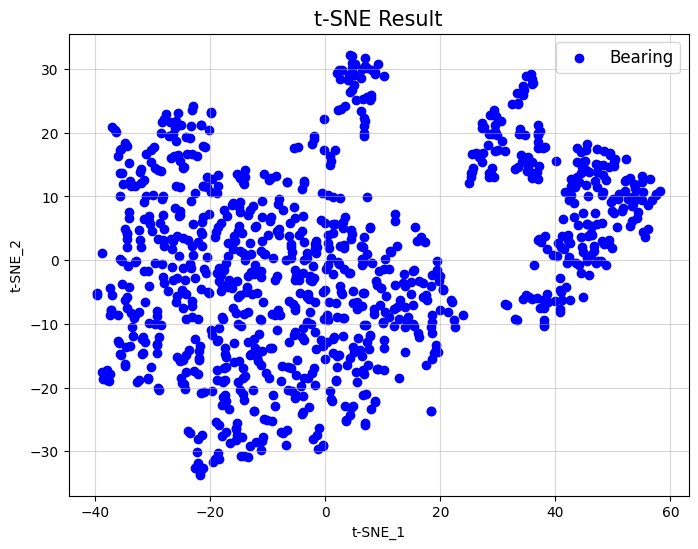

In [28]:
# Visualize Bearing 1 data
plt.figure(figsize=(8,6))

plt.scatter(tsne_results[:,0], tsne_results[:,1], marker='o', label='Bearing', c='b')
plt.title('t-SNE Result', fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel('t-SNE_1')
plt.ylabel('t-SNE_2')

plt.show()

.

.

.

### Adding a Colorbar to Show Trends

When we plot the t-SNE results, each point corresponds to one data sample.  
To show how the samples progress over time, we can **map the sample index to a color**.

- In `plt.scatter(...)`, the argument `c=order` assigns a different color to each sample based on its order (early → late).  
- The argument `cmap='RdYlGn_r'` specifies the color scale (here, green → red).  

By adding a **colorbar**, we can clearly see the trend:

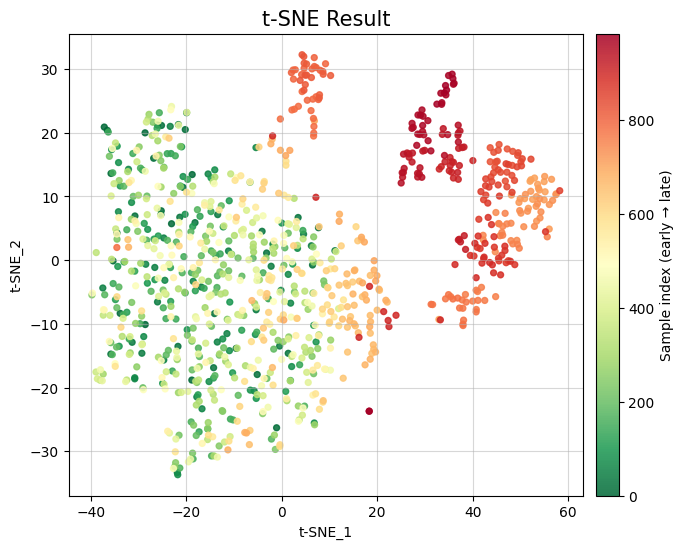

In [29]:
N = tsne_results.shape[0]                 # 984
order = np.arange(N)                      # 0,1,2,...,983 (early -> late)

plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_results[:,0], tsne_results[:,1],
                 c=order, cmap='RdYlGn_r',  # reversed so low=green, high=red
                 s=18, alpha=0.85)

plt.title('t-SNE Result', fontsize=15)
plt.xlabel('t-SNE_1')
plt.ylabel('t-SNE_2')
plt.grid(alpha=0.5)

cb = plt.colorbar(sc, pad=0.02)
cb.set_label('Sample index (early → late)')
plt.show()

.

.

.

### Interactive Visualization Tool

`plt.scatter` works well, but it produces a **static image** — you cannot zoom in, hover over points, or see extra details.



### 🔎 Plotly Package

**Plotly Express** is a library that makes plots **interactive**:

- You can **hover your mouse** over each point to see its index and coordinates.  
- You can **zoom in/out** and **pan** around the scatter plot.  
- The color of each point is mapped to its **sample index**, so you can visually track how the data changes over time.  
- A **color bar** is automatically added, which helps interpret the meaning of the colors.  



### ⚖️ Matplotlib vs. Plotly (simple comparison)

- **Matplotlib** → static plots, good for quick and simple visualizations.  
- **Plotly** → interactive plots, better for exploring data in more detail.  


In [30]:
import plotly.express as px

N = tsne_results.shape[0]
df_plot = pd.DataFrame({
    "x": tsne_results[:,0],
    "y": tsne_results[:,1],
    "index": np.arange(N)   # Sample index (0→N-1)
})

fig = px.scatter(
    df_plot, x="x", y="y", color="index",
    color_continuous_scale="RdYlGn_r",
    hover_data={"index": True, "x":":.2f", "y":":.2f"},
    labels={"index":"Sample index", "x":"t-SNE_1", "y":"t-SNE_2"},
)

fig.update_traces(marker=dict(size=7, opacity=0.85))
fig.update_layout(title="t-SNE Result", font=dict(size=15))
fig.show()